# MNIST Digit Recognition with CNN

Classifying handwritten digits (0–9) from the MNIST dataset using a Convolutional Neural Network built with the Keras functional API.

MNIST has 70000 grayscale images at 28×28 pixels  60k for training and 10k for testing.

### Why not just use a Dense network?
Dense layers treat every pixel independently. CNNs slide filters across the image so they actually pick up on edges, curves, and shapes exactly what you need for recognizing digits.

### What we're building
A 3block CNN using the **Functional API** (more flexible than Sequential) with Batch Normalization and Early Stopping to avoid overfitting.

```
Input → [Conv → BN → ReLU → MaxPool] × 3 → Flatten → Dense → Dropout → Softmax
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

## Step 1 Load and Preprocess the Data

In [2]:
# Load MNIST directly from Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1] — helps the optimizer converge faster
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# CNN expects (height, width, channels) — MNIST is grayscale so channel = 1
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print(f'Training set : {x_train.shape}  |  Labels: {y_train.shape}')
print(f'Test set     : {x_test.shape}  |  Labels: {y_test.shape}')

Training set : (60000, 28, 28, 1)  |  Labels: (60000,)
Test set     : (10000, 28, 28, 1)  |  Labels: (10000,)


## Step 2 checking at the Data

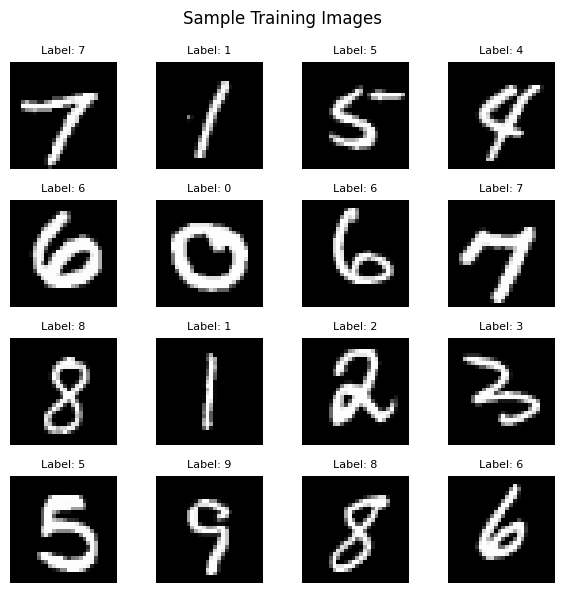

In [4]:
# Shows a 4x4 grid of random training samples just to sanity check the data
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
indices = np.random.choice(len(x_train), 16, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[idx]}', fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Training Images', fontsize=12)
plt.tight_layout()
plt.show()

## Step 3 Build the CNN

In [5]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    """
    3-block CNN using the Keras Functional API.
    Each block: Conv2D -> BatchNorm -> MaxPool
    BatchNorm stabilizes training and lets us push harder without exploding gradients.
    """
    inputs = Input(shape=input_shape)

    # Block 1 to 32 filters catch low-level stuff: edges  corners
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Block 2 to 64 filters start recognizing digit parts (curves, loops)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    # Block 3 to 128 filters combine those features into higherlevel patterns
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # Flatten and classify
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)  # randomly drop 40% of neurons during training to prevent overfitting
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='mnist_cnn')


model = build_cnn()
model.summary()

Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,026 (6.49 MB)

 Trainable params: 1,701,578 (6.49 MB)

 Non-trainable params: 448 (1.75 KB)

## Step 4  Compile the Model

In [6]:
# Adam adapts the learning rate per parameter  works great out of the box
# sparse_categorical_crossentropy is used when labels are plain integers (not one-hot)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Step 5 Train with Early Stopping

In [8]:
# Early stopping watches val_loss if it doesn't improve for 3 epochs training stops
# restore_best_weights=True means we get the best checkpoint not just the last one
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    x_train, y_train,
    epochs=15,             # upper limit early stopping usually kicks in well before this
    batch_size=256,
    validation_split=0.1,  # hold out 10% of training data for validation
    callbacks=[early_stop]
)

Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.9491 - loss: 0.1779 - val_accuracy: 0.4962 - val_loss: 2.4706
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.9851 - loss: 0.0495 - val_accuracy: 0.8732 - val_loss: 0.4999
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.9893 - loss: 0.0347 - val_accuracy: 0.9865 - val_loss: 0.0477
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 458s 2s/step - accuracy: 0.9903 - loss: 0.0294 - val_accuracy: 0.9882 - val_loss: 0.0533
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 518s 2s/step - accuracy: 0.9928 - loss: 0.0217 - val_accuracy: 0.9910 - val_loss: 0.0472
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 519s 2s/step - accuracy: 0.9942 - loss: 0.0193 - val_accuracy: 0.9908 - val_loss: 0.0476
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.9950 - loss: 0.0164 - val_accuracy: 0.9892 - val_loss: 0.0487
Epoch 8/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.9949 - loss: 0.0155 - val_accu

## Step 6 Evaluate on the test Set

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)')

## Step 7 Training curves

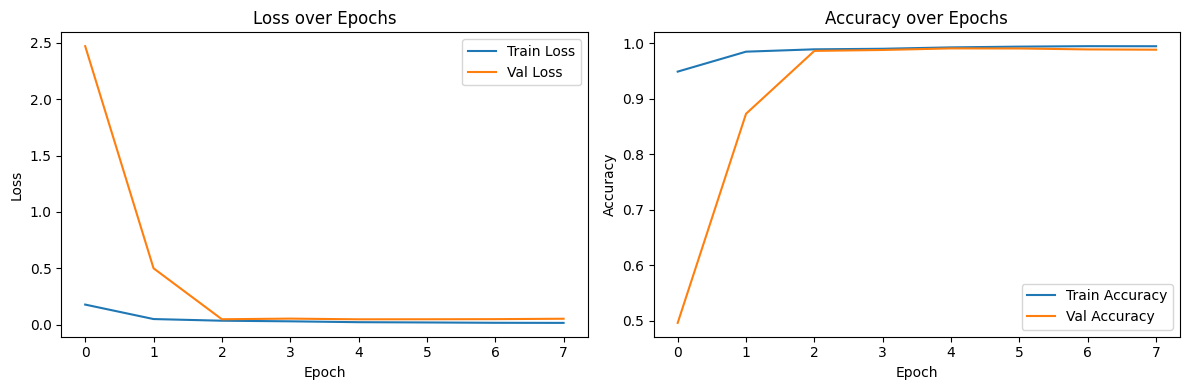

In [9]:
# Plotting the loss and accuracy side by side  easier to spot overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

## Step 8  Classification Report and the Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.98      1.00      0.99       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



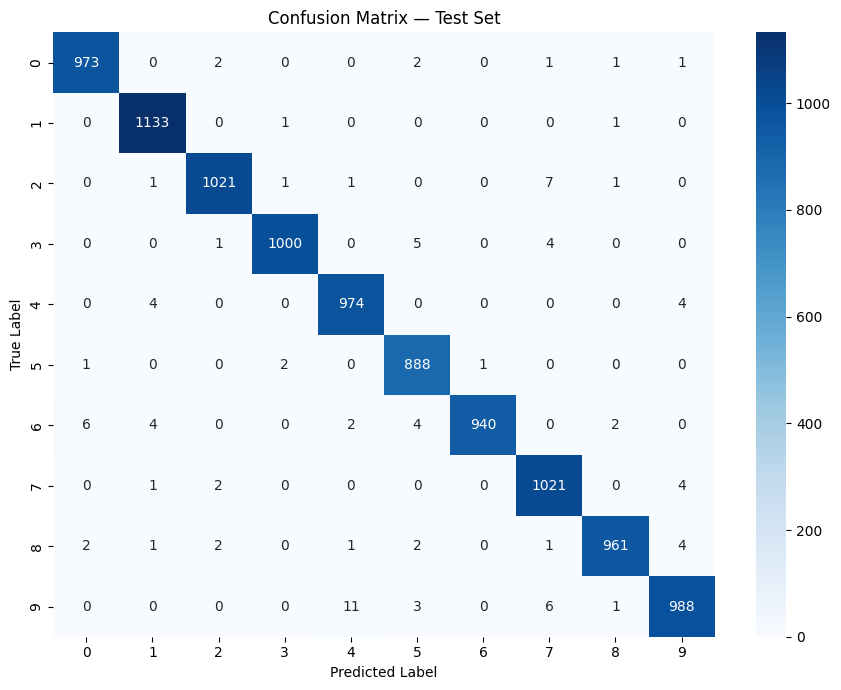

In [10]:
# Get predictions for the entire test set
y_pred_probs = model.predict(x_test)
y_pred = y_pred_probs.argmax(axis=1)

# Perclass precision, recall, F1
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

# Confusion matrix as a heatmap great for spotting which digits get confused
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## Step 9 Single Sample Prediction

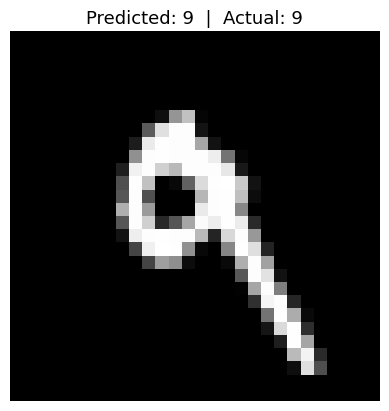

Correct!


In [11]:
# Change sample_idx to test on any image from the test set
sample_idx = 7

sample = x_test[sample_idx].reshape(1, 28, 28, 1)
predicted_label = model.predict(sample, verbose=0).argmax()
actual_label = y_test[sample_idx]

plt.imshow(x_test[sample_idx].reshape(28, 28), cmap='gray')
plt.title(f'Predicted: {predicted_label}  |  Actual: {actual_label}', fontsize=13)
plt.axis('off')
plt.show()

print('Correct!' if predicted_label == actual_label else 'Wrong prediction')